# Fine-tuning DistilBERT (cahya/distilbert-base-indonesian) untuk Semantic Search
**Pendekatan:** Contrastive Learning (In-batch Negatives / InfoNCE) dengan `categoryId` sebagai weak label

Notebook ini **terpisah** dari notebook utama (`distilbert-cahya.ipynb`). Alurnya:
1. Load & preprocessing dataset arsip (sama seperti notebook utama)
2. Bangun pasangan positif (anchor, positive) dari dokumen dengan `categoryId` yang sama
3. Fine-tuning DistilBERT dengan symmetric InfoNCE loss (in-batch negatives)
4. Simpan model hasil fine-tuning (siap dijadikan Kaggle Dataset/Model)
5. Sanity check: bandingkan cosine similarity intra-category vs inter-category sebelum & sesudah fine-tuning


## 1️. Instalasi & Import Library

In [1]:
# Install library yang dibutuhkan (khusus Kaggle environment)
!pip install -q transformers openpyxl

In [2]:
import re
import time
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from IPython.display import display

# Reproducibility
SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('✅ Semua library berhasil diimport')
print(f'   PyTorch version : {torch.__version__}')
print(f'   Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')

✅ Semua library berhasil diimport
   PyTorch version : 2.10.0+cu128
   Device          : GPU


## 2️. Load Dataset

In [3]:
# ── Sesuaikan path dengan lokasi file di Kaggle (samakan dengan notebook utama) ──
FILE_PATH = '/kaggle/input/datasets/muhammadhaekal74/dataset-arsip/dataset_arsip.xlsx'

df = pd.read_excel(FILE_PATH)

print(f'✅ Dataset berhasil dimuat')
print(f'   Jumlah baris   : {len(df):,}')
print(f'   Jumlah kolom   : {len(df.columns)}')
display(df[['title', 'description', 'keywords', 'categoryId']].head(3))

✅ Dataset berhasil dimuat
   Jumlah baris   : 784
   Jumlah kolom   : 18


,title,description,keywords,categoryId
0,Pengangkatan tim Perumus Visi dan Misi Univers...,Dokumen ini berisi tentang amanat Rektor perih...,"SK, Rektor, pengangkatan, tim perumus, visi da...",3
1,Visi dan Misi Universitas Darussalam Gontor,Dokumen ini berisi tentang Visi dan Misi Unive...,"SK, Keputusan, Rektor, Visi dan Misi, UNIDA",3
2,Penetapan Struktur Fungsionaris Centre For Isl...,Dokumen ini berisi tentang nama - nama yang di...,"SK, Rektor, Fungsionaris, CIES, UNIDA",3


## 3️. Preprocessing (identik dengan notebook utama)

In [4]:
def clean_text(text: str) -> str:
    """Bersihkan teks: lowercase, hapus karakter khusus, normalisasi spasi."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def build_combined_text(row: pd.Series) -> str:
    """Gabungkan kolom title + description + keywords menjadi satu teks."""
    parts = [
        clean_text(str(row.get('title', ''))),
        clean_text(str(row.get('description', ''))),
        clean_text(str(row.get('keywords', '')))
    ]
    return ' '.join(p for p in parts if p)


df['combined_text'] = df.apply(build_combined_text, axis=1)
df = df[df['combined_text'].str.strip() != ''].reset_index(drop=True)

print('✅ Preprocessing selesai')
print(f'   Dokumen valid  : {len(df):,}')
print()
print('Distribusi categoryId:')
display(df['categoryId'].value_counts().sort_index())

✅ Preprocessing selesai
   Dokumen valid  : 784

Distribusi categoryId:


categoryId
1     77
3    324
4     19
5     57
6     75
7     25
8    207
Name: count, dtype: int64

## 4️. Membangun Pasangan Positif (Anchor, Positive) dari `categoryId`

Asumsi weak-supervision: dua dokumen dengan `categoryId` sama dianggap **positif**
(semantik mirip). Negatif tidak perlu dibuat manual — dipakai **in-batch negatives**
(semua pasangan lain dalam satu batch otomatis jadi negatif saat training).

Jumlah pasangan per kategori dibatasi (`MAX_PAIRS_PER_CATEGORY`) supaya training tidak
timpang ke kategori dengan dokumen sangat banyak dan tetap efisien untuk ±784 dokumen.

In [5]:
MAX_PAIRS_PER_CATEGORY = 300  # batas atas pasangan per kategori, sesuaikan bila perlu
VAL_SIZE = 0.15                # porsi dokumen untuk validasi

# ── Split dokumen train/val (stratified by categoryId) ────────────
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, test_size=VAL_SIZE, stratify=df['categoryId'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'✅ Split dokumen: {len(train_df)} train, {len(val_df)} val')


def generate_positive_pairs(df, text_col='combined_text', category_col='categoryId',
                             max_pairs_per_category=MAX_PAIRS_PER_CATEGORY, seed=SEED):
    rng = random.Random(seed)
    pairs = []

    for cat, group in df.groupby(category_col):
        texts = group[text_col].tolist()
        n = len(texts)
        if n < 2:
            continue  # butuh minimal 2 dokumen untuk bikin pasangan

        idx_pairs = list(itertools.combinations(range(n), 2))
        if len(idx_pairs) > max_pairs_per_category:
            idx_pairs = rng.sample(idx_pairs, max_pairs_per_category)

        for i, j in idx_pairs:
            pairs.append((texts[i], texts[j]))

    rng.shuffle(pairs)
    return pairs


train_pairs = generate_positive_pairs(train_df)
val_pairs = generate_positive_pairs(val_df)

print(f'✅ Pasangan positif — train: {len(train_pairs):,}, val: {len(val_pairs):,}')
print()
print('Contoh 1 pasangan (train):')
print(' A:', train_pairs[0][0][:120], '...')
print(' B:', train_pairs[0][1][:120], '...')

✅ Split dokumen: 666 train, 118 val
✅ Pasangan positif — train: 1,830, val: 758

Contoh 1 pasangan (train):
 A: sop ujian skripsi sop ujian skripsi merupakan standar operasional prosedur yang memiliki kualifikasi pelaksana dalam mem ...
 B: sop pelaksanaan kerjasama sop pelaksanaan kerjasama merupakan standar operasional prosedur yang memiliki kualifikasi mem ...


## 5️. Load Model Dasar (Base Model)

In [6]:
MODEL_NAME = 'cahya/distilbert-base-indonesian'
MAX_LENGTH = 256
BATCH_SIZE = 16     # ukuran batch = jumlah in-batch negatives, sesuaikan dgn VRAM
EPOCHS     = 8
LR         = 2e-5
TEMPERATURE = 0.05  # suhu untuk InfoNCE, umum di kisaran 0.02–0.1

print(f'🔄 Memuat model dasar "{MODEL_NAME}" ke {DEVICE.upper()}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
print('✅ Model dasar berhasil dimuat')

🔄 Memuat model dasar "cahya/distilbert-base-indonesian" ke CUDA...


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/273M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/273M [00:00<?, ?B/s]

DistilBertModel LOAD REPORT from: cahya/distilbert-base-indonesian
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model dasar berhasil dimuat


In [7]:
def mean_pooling(model_output, attention_mask):
    """Mean Pooling: rata-rata token embedding yang valid (bukan padding)."""
    token_embeddings = model_output.last_hidden_state
    mask_expanded    = attention_mask.unsqueeze(-1).float()
    sum_embeddings   = (token_embeddings * mask_expanded).sum(1)
    sum_mask         = mask_expanded.sum(1).clamp(min=1e-9)
    return sum_embeddings / sum_mask


@torch.no_grad()
def encode_texts_eval(texts, batch_size=BATCH_SIZE):
    """Encode tanpa gradient — dipakai untuk sanity check sebelum/sesudah fine-tuning."""
    model.eval()
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                             max_length=MAX_LENGTH, return_tensors='pt').to(DEVICE)
        output = model(**encoded)
        emb = mean_pooling(output, encoded['attention_mask'])
        emb = F.normalize(emb, p=2, dim=1)
        all_embeddings.append(emb.cpu().numpy())
    return np.vstack(all_embeddings).astype(np.float32)


print('✅ Fungsi mean_pooling & encode_texts_eval siap')

✅ Fungsi mean_pooling & encode_texts_eval siap


## 5.1 Sanity Check — Sebelum Fine-tuning

Ambil beberapa dokumen dari 2 kategori berbeda, lalu bandingkan rata-rata cosine
similarity **intra-category** (harus tinggi) vs **inter-category** (harus rendah).
Ini jadi baseline pembanding setelah fine-tuning.

In [8]:
def intra_inter_similarity(df, n_per_cat=15, n_cats=2, seed=SEED):
    rng = random.Random(seed)
    cats = df['categoryId'].value_counts()
    cats = cats[cats >= n_per_cat].index.tolist()
    chosen_cats = rng.sample(cats, min(n_cats, len(cats)))

    sample_df = pd.concat([
        df[df['categoryId'] == c].sample(n=n_per_cat, random_state=seed)
        for c in chosen_cats
    ]).reset_index(drop=True)

    embeddings = encode_texts_eval(sample_df['combined_text'].tolist())
    sim_matrix = embeddings @ embeddings.T
    cats_arr = sample_df['categoryId'].values

    intra_sims, inter_sims = [], []
    n = len(sample_df)
    for i in range(n):
        for j in range(i + 1, n):
            if cats_arr[i] == cats_arr[j]:
                intra_sims.append(sim_matrix[i, j])
            else:
                inter_sims.append(sim_matrix[i, j])

    return np.mean(intra_sims), np.mean(inter_sims), chosen_cats


intra_before, inter_before, chosen_cats = intra_inter_similarity(df)
print('===== SEBELUM FINE-TUNING =====')
print(f'   Kategori sampel        : {chosen_cats}')
print(f'   Rata-rata sim intra    : {intra_before:.4f}')
print(f'   Rata-rata sim inter    : {inter_before:.4f}')
print(f'   Selisih (intra-inter)  : {intra_before - inter_before:.4f}')

===== SEBELUM FINE-TUNING =====
   Kategori sampel        : [1, 8]
   Rata-rata sim intra    : 0.8173
   Rata-rata sim inter    : 0.7203
   Selisih (intra-inter)  : 0.0971


## 6️. Dataset & DataLoader untuk Training

In [9]:
class PairDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]


def collate_fn(batch):
    anchors   = [a for a, p in batch]
    positives = [p for a, p in batch]
    return anchors, positives


train_dataset = PairDataset(train_pairs)
train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, drop_last=True
)

val_dataset = PairDataset(val_pairs)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, drop_last=True
)

print(f'✅ DataLoader siap — {len(train_loader)} batch train, {len(val_loader)} batch val (batch_size={BATCH_SIZE})')

✅ DataLoader siap — 114 batch train, 47 batch val (batch_size=16)


## 7️. Training — Symmetric InfoNCE (In-batch Negatives)

Untuk satu batch berisi N pasangan (anchor, positive):
1. Semua anchor & positive di-encode bersama lalu di-mean-pool & dinormalisasi
2. Similarity matrix (N × N) = anchor · positiveᵀ / temperature
3. Label yang benar ada di diagonal (anchor ke-i cocok dengan positive ke-i)
4. Loss = rata-rata cross-entropy(sim, label) dua arah (anchor→positive dan positive→anchor)

Ini setara dengan Multiple Negatives Ranking Loss / SimCSE-style contrastive loss.

In [10]:
def compute_contrastive_loss(anchors, positives, mdl):
    texts = anchors + positives
    encoded = tokenizer(texts, padding=True, truncation=True,
                         max_length=MAX_LENGTH, return_tensors='pt').to(DEVICE)

    output = mdl(**encoded)
    embeddings = mean_pooling(output, encoded['attention_mask'])
    embeddings = F.normalize(embeddings, p=2, dim=1)

    n = len(anchors)
    anchor_emb = embeddings[:n]
    pos_emb    = embeddings[n:]

    sim_matrix = anchor_emb @ pos_emb.T / TEMPERATURE
    labels = torch.arange(n, device=DEVICE)

    loss_a2p = F.cross_entropy(sim_matrix, labels)
    loss_p2a = F.cross_entropy(sim_matrix.T, labels)
    return (loss_a2p + loss_p2a) / 2


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
loss_history = []
val_loss_history = []

for epoch in range(EPOCHS):
    # ── Training ──────────────────────────────────────────────
    model.train()
    epoch_losses = []

    for anchors, positives in train_loader:
        optimizer.zero_grad()
        loss = compute_contrastive_loss(anchors, positives, model)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    avg_loss = float(np.mean(epoch_losses))
    loss_history.append(avg_loss)

    # ── Validation ────────────────────────────────────────────
    model.eval()
    epoch_val_losses = []
    with torch.no_grad():
        for anchors, positives in val_loader:
            val_loss = compute_contrastive_loss(anchors, positives, model)
            epoch_val_losses.append(val_loss.item())

    avg_val_loss = float(np.mean(epoch_val_losses))
    val_loss_history.append(avg_val_loss)

    print(f'Epoch {epoch+1:>2}/{EPOCHS} — Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

print()
print('✅ Fine-tuning selesai')

Epoch  1/8 — Train Loss: 1.2820 | Val Loss: 1.6463
Epoch  2/8 — Train Loss: 1.0707 | Val Loss: 1.6460
Epoch  3/8 — Train Loss: 1.0747 | Val Loss: 1.6636
Epoch  4/8 — Train Loss: 1.0542 | Val Loss: 1.6545
Epoch  5/8 — Train Loss: 1.0357 | Val Loss: 1.7613
Epoch  6/8 — Train Loss: 1.0214 | Val Loss: 1.7235
Epoch  7/8 — Train Loss: 0.9750 | Val Loss: 1.8772
Epoch  8/8 — Train Loss: 0.9305 | Val Loss: 1.8887

✅ Fine-tuning selesai


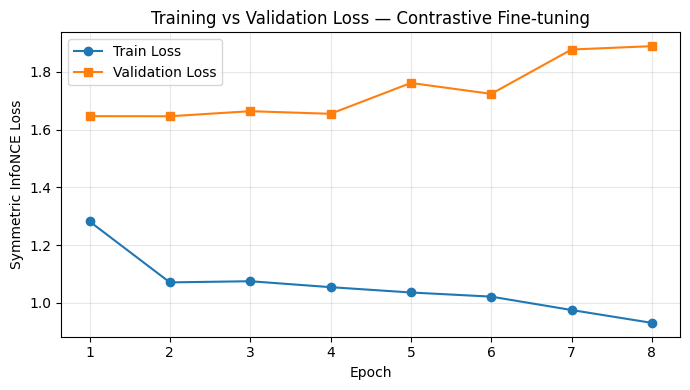

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_loss_history, marker='s', label='Validation Loss')
plt.title('Training vs Validation Loss — Contrastive Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Symmetric InfoNCE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150)
plt.show()

## 8️. Sanity Check — Sesudah Fine-tuning

In [12]:
intra_after, inter_after, _ = intra_inter_similarity(df, seed=SEED)

comparison = pd.DataFrame({
    'Metrik': ['Rata-rata sim intra-category', 'Rata-rata sim inter-category', 'Selisih (intra - inter)'],
    'Sebelum Fine-tuning': [f'{intra_before:.4f}', f'{inter_before:.4f}', f'{intra_before - inter_before:.4f}'],
    'Sesudah Fine-tuning': [f'{intra_after:.4f}', f'{inter_after:.4f}', f'{intra_after - inter_after:.4f}'],
})
display(comparison)

print()
if (intra_after - inter_after) > (intra_before - inter_before):
    print('✅ Fine-tuning meningkatkan separasi antar kategori (indikasi awal positif).')
else:
    print('⚠️ Separasi belum meningkat — pertimbangkan tambah epoch, atur ulang LR/temperature,')
    print('   atau tambah MAX_PAIRS_PER_CATEGORY.')

,Metrik,Sebelum Fine-tuning,Sesudah Fine-tuning
0,Rata-rata sim intra-category,0.8173,0.8512
1,Rata-rata sim inter-category,0.7203,0.3244
2,Selisih (intra - inter),0.0971,0.5268



✅ Fine-tuning meningkatkan separasi antar kategori (indikasi awal positif).


## 8.1 Eksperimen Multi-Seed — Validasi Stabilitas Training

Mengulang **seluruh proses training dari awal** (pembentukan pasangan positif → training dari model dasar fresh) untuk 5 seed berbeda: `[42, 123, 2024, 7, 99]`. Tujuannya membuktikan hasil fine-tuning tidak kebetulan bagus di satu seed saja, dan menghasilkan **Mean ± Std** dari `final_loss` dan `separation_gap` (intra − inter category similarity) sebagai bukti reproducibility metodologis.

> Sel ini menjalankan training 5× penuh (5× lebih lama dari training tunggal). Model dasar di-*load* ulang fresh di setiap seed — bukan melanjutkan dari model yang sudah di-fine-tune sebelumnya.

In [13]:
# ══════════════════════════════════════════════════════════════════
# EKSPERIMEN MULTI-SEED — Training Ulang dari Awal untuk 5 Seed
# ══════════════════════════════════════════════════════════════════
SEEDS = [42, 123, 2024, 7, 99]

multiseed_results = []

for exp_seed in SEEDS:
    print('=' * 60)
    print(f'🔁 Training dengan SEED = {exp_seed}')
    print('=' * 60)

    torch.manual_seed(exp_seed)
    np.random.seed(exp_seed)
    random.seed(exp_seed)

    # ── Split & pasangan positif dengan seed ini ─────────────────
    exp_train_df, exp_val_df = train_test_split(
        df, test_size=VAL_SIZE, stratify=df['categoryId'], random_state=exp_seed
    )
    exp_train_pairs = generate_positive_pairs(exp_train_df, seed=exp_seed)
    exp_val_pairs = generate_positive_pairs(exp_val_df, seed=exp_seed)

    exp_train_loader = DataLoader(
        PairDataset(exp_train_pairs), batch_size=BATCH_SIZE, shuffle=True,
        collate_fn=collate_fn, drop_last=True
    )
    exp_val_loader = DataLoader(
        PairDataset(exp_val_pairs), batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=collate_fn, drop_last=True
    )

    # ── Model dasar fresh (reset dari pretrained, bukan lanjutan) ─
    exp_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
    exp_optimizer = torch.optim.AdamW(exp_model.parameters(), lr=LR, weight_decay=0.01)

    exp_train_loss_history, exp_val_loss_history = [], []

    for epoch in range(EPOCHS):
        exp_model.train()
        epoch_losses = []
        for anchors, positives in exp_train_loader:
            exp_optimizer.zero_grad()
            loss = compute_contrastive_loss(anchors, positives, exp_model)
            loss.backward()
            exp_optimizer.step()
            epoch_losses.append(loss.item())
        avg_loss = float(np.mean(epoch_losses))
        exp_train_loss_history.append(avg_loss)

        exp_model.eval()
        epoch_val_losses = []
        with torch.no_grad():
            for anchors, positives in exp_val_loader:
                val_loss = compute_contrastive_loss(anchors, positives, exp_model)
                epoch_val_losses.append(val_loss.item())
        avg_val_loss = float(np.mean(epoch_val_losses))
        exp_val_loss_history.append(avg_val_loss)

        print(f'  Epoch {epoch+1:>2}/{EPOCHS} — Train: {avg_loss:.4f} | Val: {avg_val_loss:.4f}')

    final_train_loss = exp_train_loss_history[-1]
    final_val_loss = exp_val_loss_history[-1]

    # ── Sanity check kualitas embedding setelah training seed ini ─
    _original_model = model
    model = exp_model
    intra_after, inter_after, _ = intra_inter_similarity(df, seed=exp_seed)
    model = _original_model

    multiseed_results.append({
        'seed': exp_seed,
        'final_train_loss': round(final_train_loss, 4),
        'final_val_loss': round(final_val_loss, 4),
        'intra_category_sim': round(intra_after, 4),
        'inter_category_sim': round(inter_after, 4),
        'separation_gap': round(intra_after - inter_after, 4),
    })

    print(f'✅ Seed {exp_seed} selesai — val_loss={final_val_loss:.4f}, gap={intra_after-inter_after:.4f}')
    print()

    del exp_model, exp_optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ══════════════════════════════════════════════════════════════════
# Ringkasan
# ══════════════════════════════════════════════════════════════════
multiseed_df = pd.DataFrame(multiseed_results)
print('=' * 60)
print('   RINGKASAN EKSPERIMEN MULTI-SEED (TRAINING)')
print('=' * 60)
display(multiseed_df)

print()
print(f"Final Train Loss : {multiseed_df['final_train_loss'].mean():.4f} ± {multiseed_df['final_train_loss'].std():.4f}")
print(f"Final Val Loss    : {multiseed_df['final_val_loss'].mean():.4f} ± {multiseed_df['final_val_loss'].std():.4f}")
print(f"Separation Gap    : {multiseed_df['separation_gap'].mean():.4f} ± {multiseed_df['separation_gap'].std():.4f}")

# ── Rekomendasi seed terbaik: val_loss terendah (bukan train_loss) ─
best_row = multiseed_df.loc[multiseed_df['final_val_loss'].idxmin()]
print()
print(f"🏆 Seed dengan val_loss terendah: {int(best_row['seed'])} (val_loss={best_row['final_val_loss']:.4f})")
print(f"   Rekomendasi: set SEED = {int(best_row['seed'])} di cell konfigurasi awal,")
print(f"   lalu jalankan ulang notebook dari atas untuk melatih model produksi final.")

🔁 Training dengan SEED = 42


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: cahya/distilbert-base-indonesian
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1/8 — Train: 1.3005 | Val: 1.6401
  Epoch  2/8 — Train: 1.0783 | Val: 1.6574
  Epoch  3/8 — Train: 1.0767 | Val: 1.6389
  Epoch  4/8 — Train: 1.0341 | Val: 1.7101
  Epoch  5/8 — Train: 1.0307 | Val: 1.8294
  Epoch  6/8 — Train: 1.0270 | Val: 1.8509
  Epoch  7/8 — Train: 0.9610 | Val: 1.8489
  Epoch  8/8 — Train: 0.9361 | Val: 2.1597
✅ Seed 42 selesai — val_loss=2.1597, gap=0.4388

🔁 Training dengan SEED = 123


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: cahya/distilbert-base-indonesian
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1/8 — Train: 1.3032 | Val: 1.6590
  Epoch  2/8 — Train: 1.0994 | Val: 1.6578
  Epoch  3/8 — Train: 1.0756 | Val: 1.7215
  Epoch  4/8 — Train: 1.0489 | Val: 1.6775
  Epoch  5/8 — Train: 1.0315 | Val: 1.8329
  Epoch  6/8 — Train: 1.0038 | Val: 1.7583
  Epoch  7/8 — Train: 0.9807 | Val: 1.8423
  Epoch  8/8 — Train: 0.9378 | Val: 1.9951
✅ Seed 99 selesai — val_loss=1.9951, gap=0.6513

   RINGKASAN EKSPERIMEN MULTI-SEED (TRAINING)


,seed,final_train_loss,final_val_loss,intra_category_sim,inter_category_sim,separation_gap
0,42,0.9361,2.1597,0.8697,0.4309,0.4388
1,123,0.9369,1.9203,0.8832,0.3158,0.5673
2,2024,0.9275,2.0545,0.8388,0.3925,0.4462
3,7,0.9305,1.8887,0.8512,0.3244,0.5268
4,99,0.9378,1.9951,0.9481,0.2969,0.6513



Final Train Loss : 0.9338 ± 0.0045
Final Val Loss    : 2.0037 ± 0.1086
Separation Gap    : 0.5261 ± 0.0886

🏆 Seed dengan val_loss terendah: 7 (val_loss=1.8887)
   Rekomendasi: set SEED = 7 di cell konfigurasi awal,
   lalu jalankan ulang notebook dari atas untuk melatih model produksi final.


## 8.2 Langkah Selanjutnya — Training Model Produksi

Setelah melihat `multiseed_df` di atas:

1. Pilih seed terbaik (default rekomendasi: `final_loss` terendah — bisa juga pilih yang `separation_gap`-nya paling dekat ke rata-rata, untuk representasi yang lebih fair).
2. Ubah `SEED = 42` di **cell konfigurasi awal** (bagian Import Library) menjadi seed terpilih.
3. Jalankan ulang notebook ini **dari cell awal sampai bagian Simpan Model** (bagian 9) — proses training tunggal yang sudah ada di notebook ini akan otomatis memakai seed terpilih tersebut sebagai model produksi final.

Section eksperimen multi-seed (8.1) di atas **tidak menghasilkan model yang disimpan** — perannya murni untuk validasi metodologi dan menentukan seed mana yang dipakai untuk training produksi.

## 9️. Simpan Model Hasil Fine-tuning

Disimpan dengan `save_pretrained()` standar HuggingFace, sehingga bisa langsung
di-load dengan `AutoModel.from_pretrained(path)` dan `AutoTokenizer.from_pretrained(path)`
di notebook utama — tidak perlu ubah kode `encode_texts()` sama sekali, cukup ganti
`MODEL_NAME`.

In [14]:
SAVE_DIR = './distilbert-arsip-finetuned'

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f'✅ Model & tokenizer tersimpan di: {SAVE_DIR}')
print()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model & tokenizer tersimpan di: ./distilbert-arsip-finetuned



In [15]:
import shutil
from IPython.display import FileLink

# Zip folder model
shutil.make_archive('distilbert-arsip-finetuned', 'zip', SAVE_DIR)

# Buat link download
FileLink('distilbert-arsip-finetuned.zip')

/kaggle/working/distilbert-arsip-finetuned.zip